In [1]:
# ============================================================
# CELDA 1 - Instalacion e importacion de librerias
# Proyecto: Clasificacion de texto con NLP y Deep Learning
# Dataset: IMDb Movie Reviews
# ============================================================

# Instalaciones necesarias en Colab
!pip install datasets -q
!pip install spacy -q
!python -m spacy download en_core_web_sm -q

# Manipulacion de datos
import pandas as pd
import numpy as np

# Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
import spacy
import re
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# Representacion numerica
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Dataset
from datasets import load_dataset

# Descargas NLTK
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Configuracion
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 5)

print("Librerias instaladas e importadas correctamente")
print(f"   PyTorch version : {torch.__version__}")
print(f"   pandas version  : {pd.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 96.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Librerias instaladas e importadas correctamente
   PyTorch version : 2.10.0+cpu
   pandas version  : 2.2.2


In [2]:
# Test rapido de librerias
import spacy
nlp = spacy.load('en_core_web_sm')
print("spaCy funciona correctamente")

import torch
print("PyTorch funciona correctamente")

from datasets import load_dataset
print("datasets funciona correctamente")

spaCy funciona correctamente
PyTorch funciona correctamente
datasets funciona correctamente


In [3]:
# ============================================================
# CELDA 2 - Carga del dataset IMDb
# Fuente: Hugging Face Datasets
# 50.000 resenas de peliculas - clasificacion binaria
# ============================================================

print("Cargando dataset IMDb desde Hugging Face...")

dataset = load_dataset("imdb")

# Convertir a DataFrame
df_train = pd.DataFrame(dataset['train'])
df_test = pd.DataFrame(dataset['test'])
df = pd.concat([df_train, df_test], ignore_index=True)

print("Dataset cargado exitosamente")
print(f"   Filas totales : {len(df):,}")
print(f"   Columnas      : {df.columns.tolist()}")
print(f"   Clases        : {df['label'].unique()}")

print("\nPrimeras filas:")
print(df.head(3).to_string())

# Guardar CSV local
df.to_csv('imdb_raw.csv', index=False)
print("\nDataset guardado como imdb_raw.csv")

Cargando dataset IMDb desde Hugging Face...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset cargado exitosamente
   Filas totales : 50,000
   Columnas      : ['text', 'label']
   Clases        : [0 1]

Primeras filas:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

ANALISIS EXPLORATORIO DE DATOS
--------------------------------------------------

1. Distribucion de clases:
   Negativo (0): 25,000 - 50.0%
   Positivo (1): 25,000 - 50.0%

2. Longitud de resenas:
   Promedio : 1309 caracteres
   Minima   : 32 caracteres
   Maxima   : 13704 caracteres


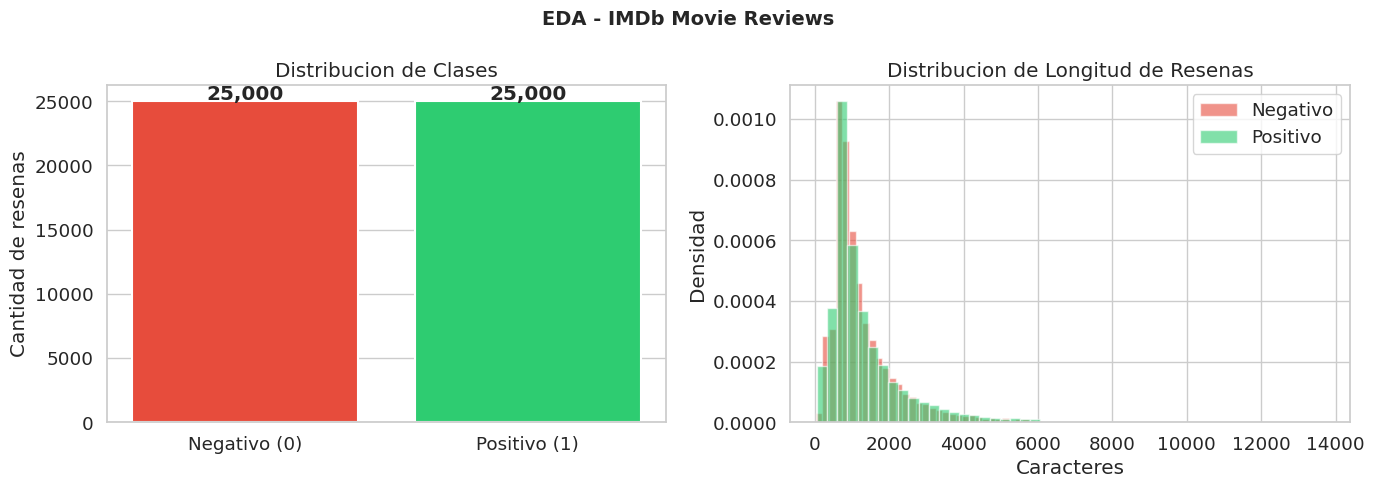

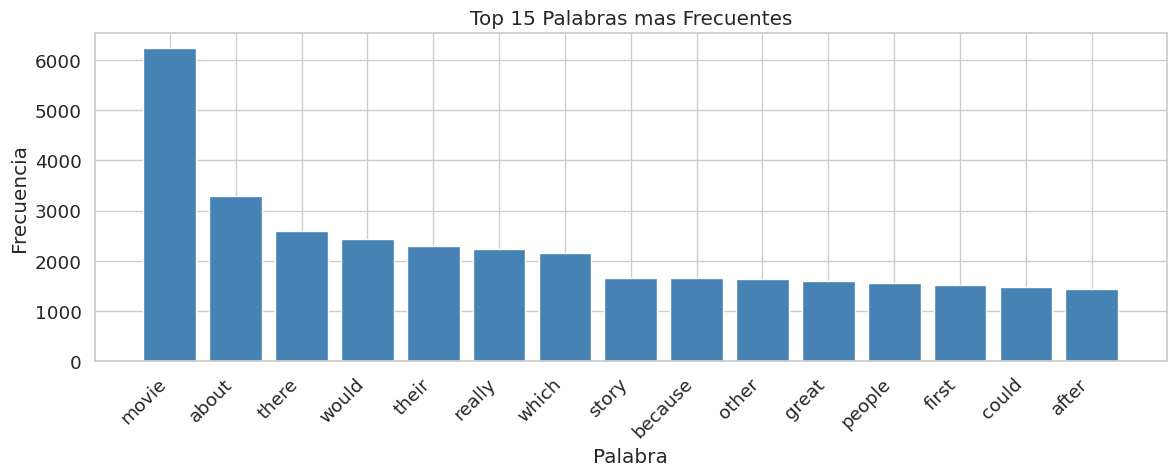

EDA completado


In [4]:
# ============================================================
# CELDA 3 - Analisis Exploratorio de Datos (EDA)
# ============================================================

print("ANALISIS EXPLORATORIO DE DATOS")
print("-" * 50)

# 1. Distribucion de clases
print("\n1. Distribucion de clases:")
conteo = df['label'].value_counts()
pct = df['label'].value_counts(normalize=True) * 100
print(f"   Negativo (0): {conteo[0]:,} - {pct[0]:.1f}%")
print(f"   Positivo (1): {conteo[1]:,} - {pct[1]:.1f}%")

# 2. Longitud de resenas
df['longitud'] = df['text'].apply(len)
print(f"\n2. Longitud de resenas:")
print(f"   Promedio : {df['longitud'].mean():.0f} caracteres")
print(f"   Minima   : {df['longitud'].min()} caracteres")
print(f"   Maxima   : {df['longitud'].max()} caracteres")

# Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1 - Distribucion de clases
colores = ['#e74c3c', '#2ecc71']
axes[0].bar(['Negativo (0)', 'Positivo (1)'],
            [conteo[0], conteo[1]],
            color=colores, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribucion de Clases')
axes[0].set_ylabel('Cantidad de resenas')
for i, v in enumerate([conteo[0], conteo[1]]):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Grafico 2 - Distribucion de longitud
axes[1].hist(df[df['label']==0]['longitud'], bins=50,
             alpha=0.6, color='#e74c3c', label='Negativo', density=True)
axes[1].hist(df[df['label']==1]['longitud'], bins=50,
             alpha=0.6, color='#2ecc71', label='Positivo', density=True)
axes[1].set_title('Distribucion de Longitud de Resenas')
axes[1].set_xlabel('Caracteres')
axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.suptitle('EDA - IMDb Movie Reviews', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Palabras mas frecuentes
from collections import Counter

# Muestra de 5000 resenas para velocidad
muestra = df['text'].sample(5000, random_state=42)
palabras = ' '.join(muestra).lower().split()
palabras_limpias = [p for p in palabras if len(p) > 4 and p.isalpha()]
frecuencias = Counter(palabras_limpias).most_common(15)

palabras_top = [p[0] for p in frecuencias]
conteos_top = [p[1] for p in frecuencias]

plt.figure(figsize=(12, 5))
plt.bar(palabras_top, conteos_top, color='steelblue', edgecolor='white')
plt.title('Top 15 Palabras mas Frecuentes')
plt.xlabel('Palabra')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('eda_palabras_frecuentes.png', dpi=150, bbox_inches='tight')
plt.show()

print("EDA completado")

In [5]:
# ============================================================
# CELDA 4 - Preprocesamiento de texto
# Limpieza con Regex, tokenizacion y lematizacion comparativa
# ============================================================

print("PREPROCESAMIENTO DE TEXTO")
print("-" * 50)

# Cargar modelo spaCy
nlp = spacy.load('en_core_web_sm')
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Funcion de limpieza con Regex
def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'<.*?>', '', texto)        # eliminar HTML
    texto = re.sub(r'http\S+|www\S+', '', texto)  # eliminar URLs
    texto = re.sub(r'[^a-z\s]', '', texto)    # solo letras
    texto = re.sub(r'\s+', ' ', texto).strip() # espacios extra
    return texto

# Lematizacion con NLTK
def lematizar_nltk(texto):
    tokens = word_tokenize(texto)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

# Lematizacion con spaCy
def lematizar_spacy(texto):
    doc = nlp(texto)
    tokens = [token.lemma_ for token in doc
              if not token.is_stop and len(token.text) > 2]
    return ' '.join(tokens)

# Aplicar sobre muestra de 5000 para velocidad
print("\nAplicando preprocesamiento sobre 5000 resenas...")
df_muestra = df.sample(5000, random_state=42).copy()

df_muestra['texto_limpio'] = df_muestra['text'].apply(limpiar_texto)
print("   Limpieza con Regex: completada")

df_muestra['texto_nltk'] = df_muestra['texto_limpio'].apply(lematizar_nltk)
print("   Lematizacion NLTK: completada")

df_muestra['texto_spacy'] = df_muestra['texto_limpio'].apply(lematizar_spacy)
print("   Lematizacion spaCy: completada")

# Comparacion de ejemplo
print("\nEJEMPLO COMPARATIVO:")
idx = df_muestra.index[0]
print(f"\nTexto original (primeros 200 chars):")
print(df_muestra.loc[idx, 'text'][:200])
print(f"\nDespues de limpieza:")
print(df_muestra.loc[idx, 'texto_limpio'][:200])
print(f"\nLematizacion NLTK:")
print(df_muestra.loc[idx, 'texto_nltk'][:200])
print(f"\nLematizacion spaCy:")
print(df_muestra.loc[idx, 'texto_spacy'][:200])

print("\nPreprocesamiento completado")

PREPROCESAMIENTO DE TEXTO
--------------------------------------------------

Aplicando preprocesamiento sobre 5000 resenas...
   Limpieza con Regex: completada
   Lematizacion NLTK: completada
   Lematizacion spaCy: completada

EJEMPLO COMPARATIVO:

Texto original (primeros 200 chars):
Forget what I said about Emeril. Rachael Ray is the most irritating personality on the Food Network AND all of television. If you've never seen 30 Minute Meals, then you cannot possibly begin to compr

Despues de limpieza:
forget what i said about emeril rachael ray is the most irritating personality on the food network and all of television if youve never seen minute meals then you cannot possibly begin to comprehend h

Lematizacion NLTK:
forget said emeril rachael ray irritating personality food network television youve never seen minute meal possibly begin comprehend unfathomably annoying really truly meant cant even begin boggled yo

Lematizacion spaCy:
forget say emeril rachael ray irritate persona

In [6]:
# ============================================================
# CELDA 5 - Representacion numerica con TF-IDF
# ============================================================

print("REPRESENTACION NUMERICA - TF-IDF")
print("-" * 50)

# Usamos el texto procesado con spaCy
X = df_muestra['texto_spacy'].values
y = df_muestra['label'].values

# Division train/test
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nDivision train/test:")
print(f"   Train: {len(X_train_text):,} resenas")
print(f"   Test : {len(X_test_text):,} resenas")

# Aplicar TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train_text).toarray()
X_test_tfidf  = tfidf.transform(X_test_text).toarray()

print(f"\nMatriz TF-IDF:")
print(f"   Train shape: {X_train_tfidf.shape}")
print(f"   Test shape : {X_test_tfidf.shape}")
print(f"   Vocabulario: {len(tfidf.vocabulary_):,} palabras")

# Convertir a tensores PyTorch
X_train_tensor = torch.FloatTensor(X_train_tfidf)
X_test_tensor  = torch.FloatTensor(X_test_tfidf)
y_train_tensor = torch.LongTensor(y_train)
y_test_tensor  = torch.LongTensor(y_test)

# DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"\nTensores PyTorch creados correctamente")
print(f"   Batches en train: {len(train_loader)}")
print(f"   Batches en test : {len(test_loader)}")
print("\nTF-IDF completado")

REPRESENTACION NUMERICA - TF-IDF
--------------------------------------------------

Division train/test:
   Train: 4,000 resenas
   Test : 1,000 resenas

Matriz TF-IDF:
   Train shape: (4000, 5000)
   Test shape : (1000, 5000)
   Vocabulario: 5,000 palabras

Tensores PyTorch creados correctamente
   Batches en train: 63
   Batches en test : 16

TF-IDF completado


In [7]:
# ============================================================
# CELDA 6 - Modelo de Deep Learning: TextClassifier
# ============================================================

print("MODELO DE DEEP LEARNING - TextClassifier")
print("-" * 50)

class TextClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, output_dim, dropout=0.5):
        super(TextClassifier, self).__init__()

        # Capa 1
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.bn1 = nn.BatchNorm1d(hidden_dim1)

        # Capa 2
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.bn2 = nn.BatchNorm1d(hidden_dim2)

        # Capa de salida
        self.fc3 = nn.Linear(hidden_dim2, output_dim)

        # Dropout y activacion
        self.dropout = nn.Dropout(p=dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        # Capa 1
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)

        # Capa 2
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)

        # Salida
        x = self.fc3(x)
        return x

# Instanciar modelo
INPUT_DIM   = 5000
HIDDEN_DIM1 = 256
HIDDEN_DIM2 = 128
OUTPUT_DIM  = 2

modelo = TextClassifier(INPUT_DIM, HIDDEN_DIM1, HIDDEN_DIM2, OUTPUT_DIM)

print("\nArquitectura del modelo:")
print(modelo)

# Contar parametros
total_params = sum(p.numel() for p in modelo.parameters())
print(f"\nTotal de parametros: {total_params:,}")
print("\nModelo creado correctamente")

MODELO DE DEEP LEARNING - TextClassifier
--------------------------------------------------

Arquitectura del modelo:
TextClassifier(
  (fc1): Linear(in_features=5000, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (relu): ReLU()
)

Total de parametros: 1,314,178

Modelo creado correctamente


In [9]:
# ============================================================
# CELDA 7 - Entrenamiento con Adam, CrossEntropy y Early Stopping
# ============================================================

print("ENTRENAMIENTO DEL MODELO")
print("-" * 50)

# Configuracion
EPOCHS        = 50
LEARNING_RATE = 0.001
PATIENCE      = 5

criterio   = nn.CrossEntropyLoss()
optimizador = optim.Adam(modelo.parameters(), lr=LEARNING_RATE)

# Variables para Early Stopping
mejor_loss_val  = float('inf')
epocas_sin_mejora = 0
mejor_modelo    = None
historial       = []

print(f"\nConfiguracion:")
print(f"   Epochs maximos : {EPOCHS}")
print(f"   Learning rate  : {LEARNING_RATE}")
print(f"   Early Stopping : {PATIENCE} epocas sin mejora")
print(f"\nEntrenando...\n")

for epoca in range(EPOCHS):

    # ENTRENAMIENTO
    modelo.train()
    loss_train = 0
    correctos_train = 0

    for X_batch, y_batch in train_loader:
        optimizador.zero_grad()
        predicciones = modelo(X_batch)
        loss = criterio(predicciones, y_batch)
        loss.backward()
        optimizador.step()
        loss_train += loss.item()
        correctos_train += (predicciones.argmax(1) == y_batch).sum().item()

    # VALIDACION
    modelo.eval()
    loss_val = 0
    correctos_val = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            predicciones = modelo(X_batch)
            loss = criterio(predicciones, y_batch)
            loss_val += loss.item()
            correctos_val += (predicciones.argmax(1) == y_batch).sum().item()

    # Metricas
    loss_train_avg = loss_train / len(train_loader)
    loss_val_avg   = loss_val / len(test_loader)
    acc_train = correctos_train / len(train_dataset)
    acc_val   = correctos_val / len(test_dataset)

    historial.append({
        'epoca'     : epoca + 1,
        'loss_train': loss_train_avg,
        'loss_val'  : loss_val_avg,
        'acc_train' : acc_train,
        'acc_val'   : acc_val
    })

    print(f"Epoca {epoca+1:2d} | Loss train: {loss_train_avg:.4f} | Loss val: {loss_val_avg:.4f} | Acc val: {acc_val:.4f}")

    # Early Stopping
    if loss_val_avg < mejor_loss_val:
        mejor_loss_val = loss_val_avg
        mejor_modelo = modelo.state_dict().copy()
        epocas_sin_mejora = 0
    else:
        epocas_sin_mejora += 1
        if epocas_sin_mejora >= PATIENCE:
            print(f"\nEarly Stopping activado en epoca {epoca+1}")
            print(f"Mejor loss de validacion: {mejor_loss_val:.4f}")
            break

print("\nEntrenamiento completado")

ENTRENAMIENTO DEL MODELO
--------------------------------------------------

Configuracion:
   Epochs maximos : 50
   Learning rate  : 0.001
   Early Stopping : 5 epocas sin mejora

Entrenando...

Epoca  1 | Loss train: 0.4982 | Loss val: 0.4661 | Acc val: 0.8020
Epoca  2 | Loss train: 0.1774 | Loss val: 0.3346 | Acc val: 0.8600
Epoca  3 | Loss train: 0.0624 | Loss val: 0.4075 | Acc val: 0.8470
Epoca  4 | Loss train: 0.0268 | Loss val: 0.4445 | Acc val: 0.8530
Epoca  5 | Loss train: 0.0137 | Loss val: 0.5038 | Acc val: 0.8420
Epoca  6 | Loss train: 0.0089 | Loss val: 0.5406 | Acc val: 0.8410
Epoca  7 | Loss train: 0.0078 | Loss val: 0.5855 | Acc val: 0.8300

Early Stopping activado en epoca 7
Mejor loss de validacion: 0.3346

Entrenamiento completado


RESULTADOS FINALES
--------------------------------------------------

Reporte de clasificacion:
              precision    recall  f1-score   support

    Negativo       0.81      0.86      0.83       499
    Positivo       0.85      0.80      0.83       501

    accuracy                           0.83      1000
   macro avg       0.83      0.83      0.83      1000
weighted avg       0.83      0.83      0.83      1000



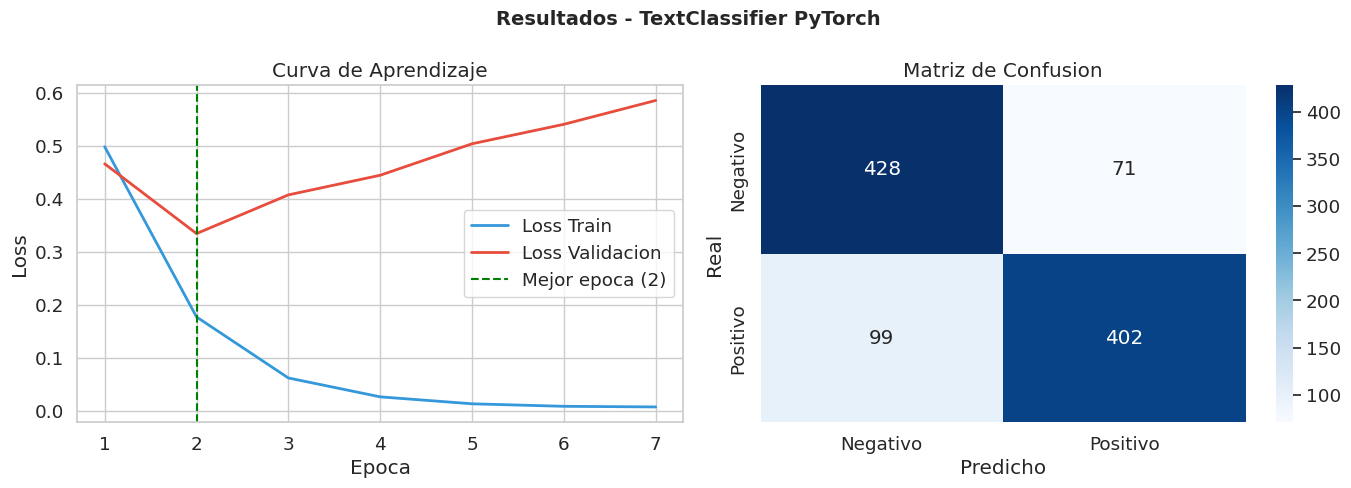

Accuracy final en test: 83.0 %
Resultados completados


In [12]:
# ============================================================
# CELDA 8 - Resultados finales y visualizacion
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix

print("RESULTADOS FINALES")
print("-" * 50)

# Cargar mejor modelo
modelo.load_state_dict(mejor_modelo)
modelo.eval()

# Predicciones finales
y_pred = []
y_real = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        predicciones = modelo(X_batch)
        y_pred.extend(predicciones.argmax(1).numpy())
        y_real.extend(y_batch.numpy())

y_pred = np.array(y_pred)
y_real = np.array(y_real)

# Reporte
print("\nReporte de clasificacion:")
print(classification_report(y_real, y_pred,
      target_names=['Negativo', 'Positivo']))

# Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1 - Curva de aprendizaje
df_hist = pd.DataFrame(historial)
axes[0].plot(df_hist['epoca'], df_hist['loss_train'],
             label='Loss Train', color='#3498db', linewidth=2)
axes[0].plot(df_hist['epoca'], df_hist['loss_val'],
             label='Loss Validacion', color='#e74c3c', linewidth=2)
axes[0].axvline(x=2, color='green', linestyle='--',
                label='Mejor epoca (2)')
axes[0].set_title('Curva de Aprendizaje')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Grafico 2 - Matriz de confusion
cm = confusion_matrix(y_real, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'],
            ax=axes[1])
axes[1].set_title('Matriz de Confusion')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

plt.suptitle('Resultados - TextClassifier PyTorch',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('resultados_modelo.png', dpi=150, bbox_inches='tight')
plt.show()

# Accuracy final
accuracy = (y_pred == y_real).mean()
print("Accuracy final en test:", round(float(accuracy)*100, 1), "%")
print("Resultados completados")

In [13]:
# CELDA - Descargar imagenes
from google.colab import files
import os

imagenes = [
    'eda_distribucion.png',
    'eda_palabras_frecuentes.png',
    'resultados_modelo.png'
]

for img in imagenes:
    if os.path.exists(img):
        files.download(img)
        print("Descargando:", img)
    else:
        print("No encontrada:", img)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: eda_distribucion.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: eda_palabras_frecuentes.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: resultados_modelo.png
